In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import sys

In [2]:
p = Path.cwd()
root = p.parents[2]
print(root)

data_folder = root.parent / 'data' / 'tiingo' / 'commods'
print(data_folder)

from strategies.trend_following.scripts.build_panel import build_panel   # or wherever it ends up
build_panel(data_folder,panel_name='commods_panel.parquet')

for file in Path(data_folder).iterdir():
    print(file)



c:\Users\luciu\code\trading_research
c:\Users\luciu\code\data\tiingo\commods
c:\Users\luciu\code\data\tiingo\commods\CANE.parquet
c:\Users\luciu\code\data\tiingo\commods\commods_panel.parquet
c:\Users\luciu\code\data\tiingo\commods\CORN.parquet
c:\Users\luciu\code\data\tiingo\commods\CPER.parquet
c:\Users\luciu\code\data\tiingo\commods\GLD.parquet
c:\Users\luciu\code\data\tiingo\commods\KRBN.parquet
c:\Users\luciu\code\data\tiingo\commods\SLV.parquet
c:\Users\luciu\code\data\tiingo\commods\SOYB.parquet
c:\Users\luciu\code\data\tiingo\commods\UGA.parquet
c:\Users\luciu\code\data\tiingo\commods\UNL.parquet
c:\Users\luciu\code\data\tiingo\commods\USL.parquet
c:\Users\luciu\code\data\tiingo\commods\WEAT.parquet


In [3]:
UNIVERSE = [
    "GLD",    # gold, physical
    "SLV",    # silver, physical
    "CPER",   # copper
    "USL",    # WTI, 12-month strip
    "UGA",    # gasoline
    "UNL",    # natural gas, 12-month strip
    "CORN",
    "WEAT",
    "SOYB",
    "CANE",   # sugar
    "KRBN",   # carbon allowances
]

In [4]:
import pandas as pd

from libs.qc.panel_quality import diagnose, clean, returns

panel = pd.read_parquet(f"{data_folder}/commods_panel.parquet")
panel.columns.names = ["ticker", "field"]
panel.index.name = "date"

px_commods = panel.xs("adjClose",  axis=1, level="field")
vol_commods = panel.xs("adjVolume", axis=1, level="field")

print(diagnose(px_commods, vol_commods))        # look before cleaning

filled, mask = clean(px_commods)
rets = returns(filled, mask)

           start         end   obs interior_nan zero_ret zero_ret_pct  \
CANE  2011-09-19  2026-09-09  3765            0      223          5.9   
CORN  2010-06-09  2026-09-09  4088            0       75          1.8   
CPER  2011-11-15  2026-09-09  3724            0      352          9.5   
GLD   2004-11-18  2026-09-09  5485            0       20          0.4   
KRBN  2020-07-30  2026-09-09  1535            0        8          0.5   
SLV   2006-04-28  2026-09-09  5123            0       78          1.5   
SOYB  2011-09-19  2026-09-09  3765            0       85          2.3   
UGA   2008-02-28  2026-09-09  4662            0       18          0.4   
UNL   2010-01-04  2026-09-09  4196            0       85          2.0   
USL   2007-12-06  2026-09-09  4718            0       45          1.0   
WEAT  2011-09-19  2026-09-09  3765            0      140          3.7   

     max_stale_run big_moves nonpositive zero_vol  
CANE             6         0           0      114  
CORN             2 

In [5]:
px_commods

ticker,CANE,CORN,CPER,GLD,KRBN,SLV,SOYB,UGA,UNL,USL,WEAT
date,,,,,,,,,,,
2004-11-18,NaN,NaN,NaN,44.38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-19,NaN,NaN,NaN,44.78,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-22,NaN,NaN,NaN,44.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-23,NaN,NaN,NaN,44.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-11-24,NaN,NaN,NaN,45.05,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-09-02,11.66,20.22,39.53,402.78,35.0900,59.07,27.62,128.91,5.9541,53.4100,27.86
2026-09-03,11.39,20.17,39.91,410.22,34.7437,60.55,27.79,131.21,5.8605,53.1790,27.12
2026-09-04,11.42,20.07,39.95,406.77,34.8800,59.82,27.65,133.22,5.8639,53.4800,26.49


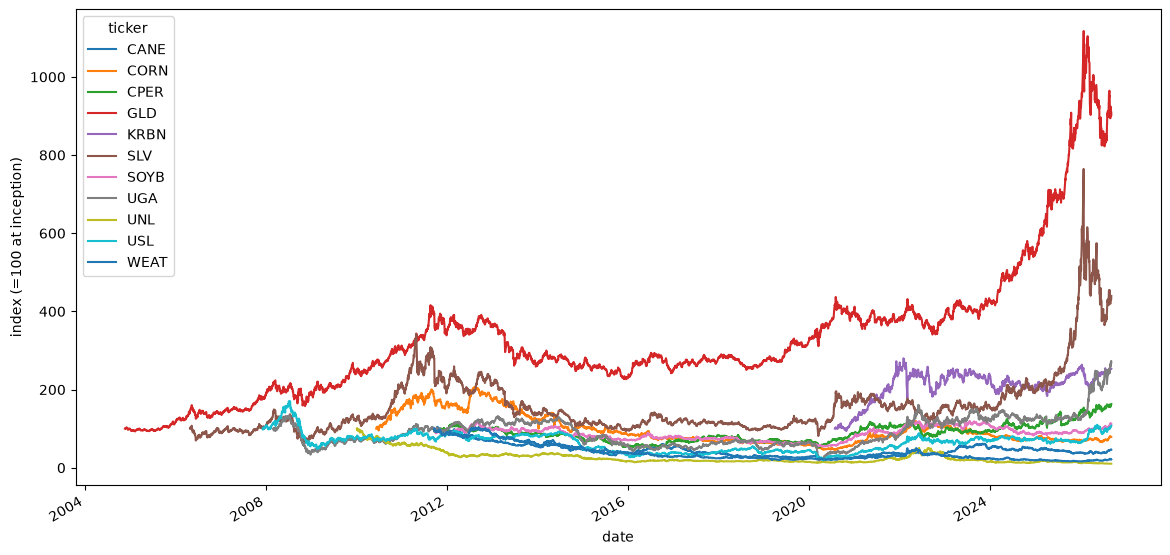

In [6]:
import matplotlib.pyplot as plt

norm = px_commods / px_commods.apply(lambda s: s.loc[s.first_valid_index()]) * 100

norm.plot(figsize=(14, 7), logy=False)
plt.ylabel("index (=100 at inception)")
plt.show()

In [7]:
p = Path.cwd()
root = p.parents[2]
print(root)

data_folder = root.parent / 'data' / 'tiingo' / 'equity'
print(data_folder)

from strategies.trend_following.scripts.build_panel import build_panel   # or wherever it ends up
build_panel(data_folder,panel_name='equities_panel.parquet')

for file in Path(data_folder).iterdir():
    print(file)



c:\Users\luciu\code\trading_research
c:\Users\luciu\code\data\tiingo\equity
c:\Users\luciu\code\data\tiingo\equity\EEM.parquet
c:\Users\luciu\code\data\tiingo\equity\EFA.parquet
c:\Users\luciu\code\data\tiingo\equity\equities_panel.parquet
c:\Users\luciu\code\data\tiingo\equity\equity_panel.parquet
c:\Users\luciu\code\data\tiingo\equity\EWJ.parquet
c:\Users\luciu\code\data\tiingo\equity\IWM.parquet
c:\Users\luciu\code\data\tiingo\equity\QQQ.parquet
c:\Users\luciu\code\data\tiingo\equity\SPY.parquet


In [8]:
import pandas as pd

from libs.qc.panel_quality import diagnose, clean, returns

panel = pd.read_parquet(f"{data_folder}/equities_panel.parquet")
panel.columns.names = ["ticker", "field"]
panel.index.name = "date"

px_eq = panel.xs("adjClose",  axis=1, level="field")
vol_eq = panel.xs("adjVolume", axis=1, level="field")

print(diagnose(px_eq, vol_eq))        # look before cleaning

filled, mask = clean(px_eq)
rets = returns(filled, mask)

          start         end   obs interior_nan zero_ret zero_ret_pct  \
EEM  2003-04-14  2026-09-09  5889            0       35          0.6   
EFA  2001-08-17  2026-09-09  6301            0       61          1.0   
EWJ  1996-04-01  2026-09-09  7659            0      279          3.6   
IWM  2000-05-26  2026-09-09  6610            0       18          0.3   
QQQ  1999-03-10  2026-09-09  6918            0       36          0.5   
SPY  1993-01-29  2026-09-09  8460            0       62          0.7   

    max_stale_run big_moves nonpositive zero_vol  
EEM             2         2           0        0  
EFA             2         0           0        1  
EWJ             3         0           0        0  
IWM             1         0           0        0  
QQQ             2         0           0        0  
SPY             2         0           0        0  


In [9]:
px_eq

ticker,EEM,EFA,EWJ,IWM,QQQ,SPY
date,,,,,,
1993-01-29,NaN,NaN,NaN,NaN,NaN,24.100764
1993-02-01,NaN,NaN,NaN,NaN,NaN,24.272178
1993-02-02,NaN,NaN,NaN,NaN,NaN,24.323574
1993-02-03,NaN,NaN,NaN,NaN,NaN,24.580722
1993-02-04,NaN,NaN,NaN,NaN,NaN,24.683571
...,...,...,...,...,...,...
2026-09-02,67.15,107.06,96.04,294.01,709.24,765.160000
2026-09-03,67.47,108.21,97.90,295.19,717.67,773.170000
2026-09-04,68.70,108.35,98.28,296.01,718.96,770.190000


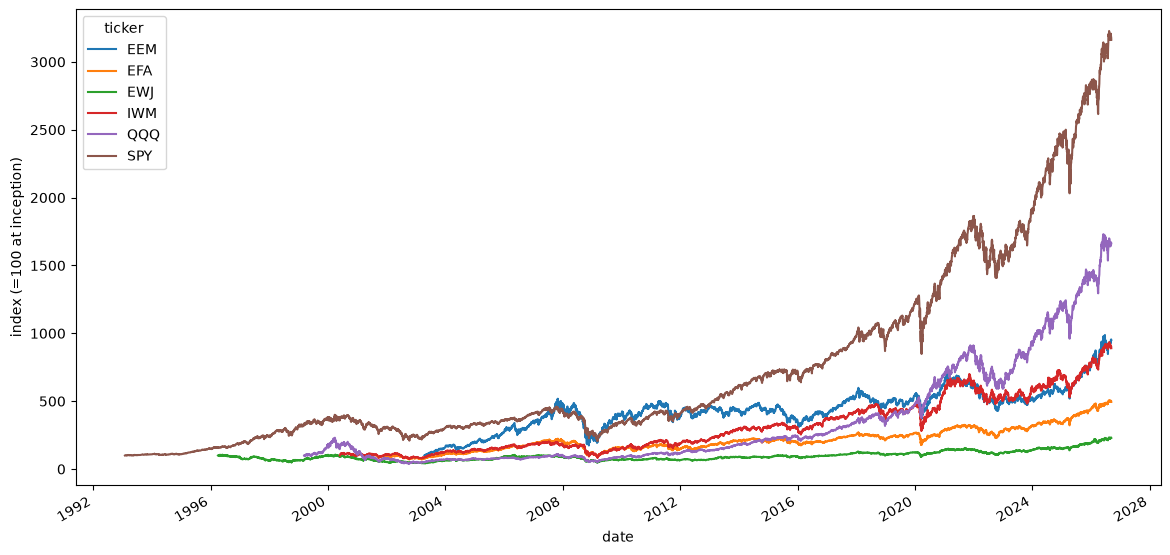

In [10]:
import matplotlib.pyplot as plt

norm = px_eq / px_eq.apply(lambda s: s.loc[s.first_valid_index()]) * 100

norm.plot(figsize=(14, 7), logy=False)
plt.ylabel("index (=100 at inception)")
plt.show()